# Introvert and Extrovert Prediction Project

This project aims to build a machine learning classification model to predict whether an individual leans toward Introversion or Extroversion based on their behavioral traits and social tendencies.

The dataset is synthetically generated using a deep learning architecture trained on the foundational "Extrovert vs. Introvert Behavior" dataset. Models will be optimized and evaluated primarily using Accuracy Score.

<img src='https://keydifferences.com/wp-content/uploads/2016/07/introvert-vs-extrovert-thumbnail.jpg' width='750'>

In [3]:
#!pip install catboost

In [6]:
#!pip install optuna

In [7]:
#Libraries
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.metrics import accuracy_score
from sklearn.preprocessing import LabelEncoder
import xgboost as xgb
import lightgbm as lgb
from catboost import CatBoostClassifier
from sklearn.ensemble import VotingClassifier
import optuna
import warnings
warnings.filterwarnings('ignore')

# EDA

In [8]:
df_train=pd.read_csv('train.csv')

In [9]:
df_test=pd.read_csv('test.csv')

In [10]:
df_train.head()

,id,Time_spent_Alone,Stage_fear,Social_event_attendance,Going_outside,Drained_after_socializing,Friends_circle_size,Post_frequency,Personality
0,0,0.0,No,6.0,4.0,No,15.0,5.0,Extrovert
1,1,1.0,No,7.0,3.0,No,10.0,8.0,Extrovert
2,2,6.0,Yes,1.0,0.0,NaN,3.0,0.0,Introvert
3,3,3.0,No,7.0,3.0,No,11.0,5.0,Extrovert
4,4,1.0,No,4.0,4.0,No,13.0,NaN,Extrovert


In [11]:
df_train.tail()

,id,Time_spent_Alone,Stage_fear,Social_event_attendance,Going_outside,Drained_after_socializing,Friends_circle_size,Post_frequency,Personality
18519,18519,3.0,No,7.0,3.0,No,9.0,7.0,Extrovert
18520,18520,1.0,NaN,6.0,7.0,No,6.0,5.0,Extrovert
18521,18521,7.0,Yes,1.0,1.0,Yes,1.0,NaN,Introvert
18522,18522,NaN,Yes,1.0,0.0,Yes,5.0,2.0,Introvert
18523,18523,1.0,No,8.0,6.0,No,4.0,7.0,Extrovert


In [12]:
df_train.shape

(18524, 9)

In [13]:
df_train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 18524 entries, 0 to 18523
Data columns (total 9 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   id                         18524 non-null  int64  
 1   Time_spent_Alone           17334 non-null  float64
 2   Stage_fear                 16631 non-null  object 
 3   Social_event_attendance    17344 non-null  float64
 4   Going_outside              17058 non-null  float64
 5   Drained_after_socializing  17375 non-null  object 
 6   Friends_circle_size        17470 non-null  float64
 7   Post_frequency             17260 non-null  float64
 8   Personality                18524 non-null  object 
dtypes: float64(5), int64(1), object(3)
memory usage: 1.3+ MB


In [14]:
df_train.isnull().sum()

id                              0
Time_spent_Alone             1190
Stage_fear                   1893
Social_event_attendance      1180
Going_outside                1466
Drained_after_socializing    1149
Friends_circle_size          1054
Post_frequency               1264
Personality                     0
dtype: int64

In [15]:
df_test.head()

,id,Time_spent_Alone,Stage_fear,Social_event_attendance,Going_outside,Drained_after_socializing,Friends_circle_size,Post_frequency
0,18524,3.0,No,7.0,4.0,No,6.0,NaN
1,18525,NaN,Yes,0.0,0.0,Yes,5.0,1.0
2,18526,3.0,No,5.0,6.0,No,15.0,9.0
3,18527,3.0,No,4.0,4.0,No,5.0,6.0
4,18528,9.0,Yes,1.0,2.0,Yes,1.0,1.0


In [16]:
df_test.shape

(6175, 8)

In [17]:
df_test.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6175 entries, 0 to 6174
Data columns (total 8 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   id                         6175 non-null   int64  
 1   Time_spent_Alone           5750 non-null   float64
 2   Stage_fear                 5577 non-null   object 
 3   Social_event_attendance    5778 non-null   float64
 4   Going_outside              5709 non-null   float64
 5   Drained_after_socializing  5743 non-null   object 
 6   Friends_circle_size        5825 non-null   float64
 7   Post_frequency             5767 non-null   float64
dtypes: float64(5), int64(1), object(2)
memory usage: 386.1+ KB


In [18]:
df_test.isnull().sum()

id                             0
Time_spent_Alone             425
Stage_fear                   598
Social_event_attendance      397
Going_outside                466
Drained_after_socializing    432
Friends_circle_size          350
Post_frequency               408
dtype: int64

In [19]:
df_train['Personality'].value_counts()

Personality
Extrovert    13699
Introvert     4825
Name: count, dtype: int64

<Axes: xlabel='Personality'>

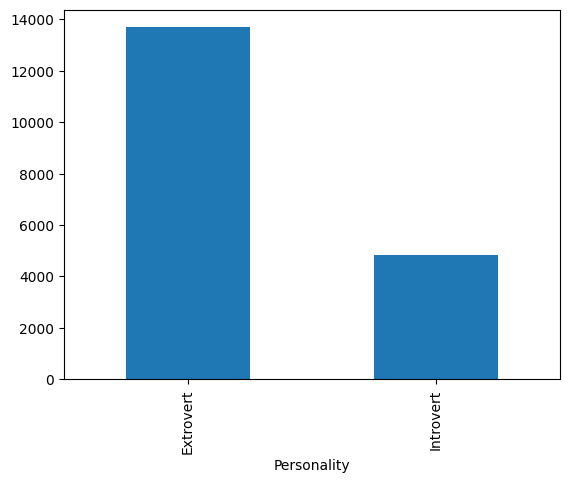

In [20]:
df_train['Personality'].value_counts().plot(kind='bar')

In [21]:
numeric = df_train.select_dtypes(include=np.number).columns.drop('id', errors='ignore').tolist()
categoric = df_train.select_dtypes(exclude=np.number).columns.drop('Personality', errors='ignore').tolist()

print(f"Numeric: {numeric}\nCategoric: {categoric}")

Numeric: ['Time_spent_Alone', 'Social_event_attendance', 'Going_outside', 'Friends_circle_size', 'Post_frequency']
Categoric: ['Stage_fear', 'Drained_after_socializing']


In [23]:
df_train.Time_spent_Alone.value_counts()

Time_spent_Alone
0.0     3139
3.0     3081
2.0     3039
1.0     2973
4.0     1079
5.0      633
10.0     587
8.0      582
7.0      581
6.0      574
9.0      574
11.0     492
Name: count, dtype: int64

<Axes: xlabel='Time_spent_Alone', ylabel='Count'>

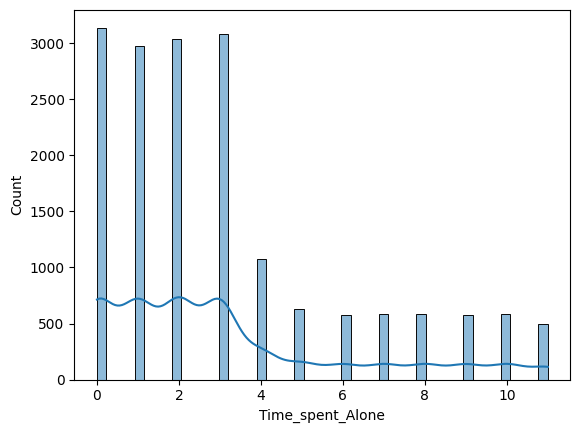

In [24]:
sns.histplot(df_train['Time_spent_Alone'], kde=True)

In [26]:
df_train.Stage_fear.value_counts()

Stage_fear
No     12609
Yes     4022
Name: count, dtype: int64

<Axes: xlabel='Stage_fear'>

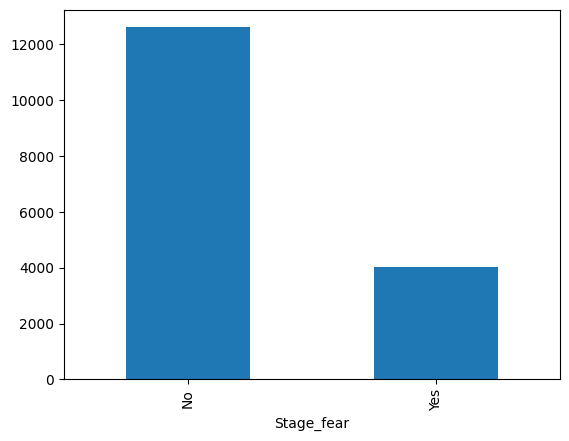

In [27]:
df_train['Stage_fear'].value_counts().plot(kind='bar')

In [28]:
df_train.Social_event_attendance.value_counts()

Social_event_attendance
4.0     2073
9.0     2063
7.0     2031
5.0     1985
6.0     1984
8.0     1945
3.0     1703
2.0     1063
0.0     1055
1.0      978
10.0     464
Name: count, dtype: int64

<Axes: xlabel='Social_event_attendance', ylabel='Count'>

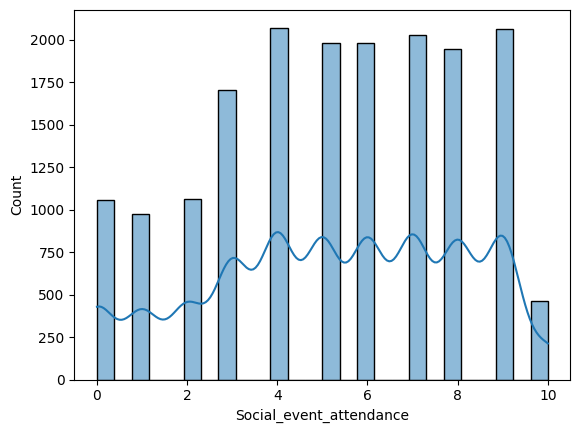

In [29]:
sns.histplot(df_train['Social_event_attendance'], kde=True)

In [30]:
df_train.Going_outside.value_counts()

Going_outside
5.0    2923
3.0    2822
4.0    2703
6.0    2702
7.0    2170
0.0    1324
2.0    1279
1.0    1135
Name: count, dtype: int64

<Axes: xlabel='Going_outside', ylabel='Count'>

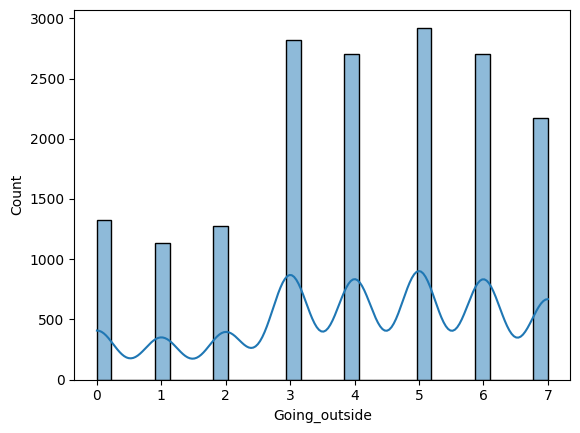

In [31]:
sns.histplot(df_train['Going_outside'], kde=True)

In [32]:
df_train.Friends_circle_size.value_counts()

Friends_circle_size
5.0     1669
4.0     1317
12.0    1317
8.0     1281
10.0    1267
11.0    1253
14.0    1188
6.0     1146
7.0     1124
9.0     1061
13.0    1048
15.0     943
3.0      866
2.0      770
1.0      753
0.0      467
Name: count, dtype: int64

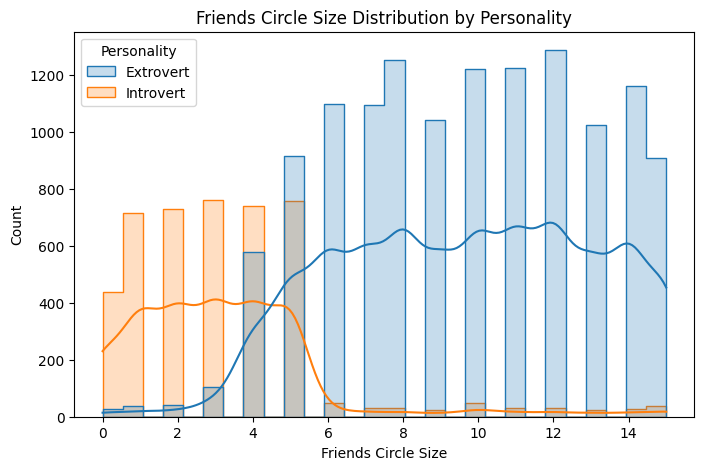

In [34]:
plt.figure(figsize=(8, 5))
sns.histplot(data=df_train, x='Friends_circle_size', hue='Personality', kde=True, element='step')
plt.title('Friends Circle Size Distribution by Personality')
plt.xlabel('Friends Circle Size')
plt.ylabel('Count')
plt.show()

### Data Processing

In [35]:
train = df_train.copy()
test = df_test.copy()

In [36]:
map_dict = {'Yes': 1, 'No': 0}
train['Stage_fear'] = train['Stage_fear'].map(map_dict)
test['Stage_fear'] = test['Stage_fear'].map(map_dict)
train['Drained_after_socializing'] = train['Drained_after_socializing'].map(map_dict)
test['Drained_after_socializing'] = test['Drained_after_socializing'].map(map_dict)

map_personality = {'Introvert': 1, 'Extrovert': 0}
train['Personality'] = train['Personality'].map(map_personality)

In [37]:
# Feature Engineering
train['Social_to_Alone_Ratio'] = train['Social_event_attendance'] / (train['Time_spent_Alone'] + 1)
test['Social_to_Alone_Ratio'] = test['Social_event_attendance'] / (test['Time_spent_Alone'] + 1)

train['Social_Volume'] = train['Friends_circle_size'] * train['Going_outside']
test['Social_Volume'] = test['Friends_circle_size'] * test['Going_outside']

### Modeling

In [39]:
x = train.drop(['Personality', 'id'], axis=1, errors='ignore') 
y = train['Personality']
test_df = test.drop(['id'], axis=1, errors='ignore') 

In [51]:
models = {"XGBoost": xgb.XGBClassifier(n_estimators=1000,learning_rate=0.05,random_state=42,n_jobs=-1,
                                       early_stopping_rounds=50,verbosity=0),
          "LightGBM": lgb.LGBMClassifier(n_estimators=1000,learning_rate=0.05,random_state=42,n_jobs=-1,
                                         verbosity=-1),
          "CatBoost": CatBoostClassifier(n_estimators=1000,learning_rate=0.05,random_state=42,verbose=0,
                                         allow_writing_files=False)}
results = {}

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
for name, model in models.items():    
    fold_scores = []
    for train_idx, val_idx in skf.split(x, y):
        X_train_fold, y_train_fold = x.iloc[train_idx], y.iloc[train_idx]
        X_val_fold, y_val_fold = x.iloc[val_idx], y.iloc[val_idx]
        if name == "XGBoost":
            model.fit(X_train_fold, y_train_fold, eval_set=[(X_val_fold, y_val_fold)], verbose=False)
        elif name == "LightGBM":
            callbacks = [lgb.early_stopping(stopping_rounds=50, verbose=False)]
            model.fit(X_train_fold, y_train_fold, eval_set=[(X_val_fold, y_val_fold)], 
                      eval_metric='binary_logloss', callbacks=callbacks)
        elif name == "CatBoost":
            model.fit(X_train_fold, y_train_fold, eval_set=(X_val_fold, y_val_fold), early_stopping_rounds=50, 
                      verbose=False)
            
        preds = model.predict(X_val_fold)
        fold_scores.append(accuracy_score(y_val_fold, preds))
    
    avg_score = np.mean(fold_scores)
    results[name] = avg_score
    print(f"{name}: {avg_score:.5f}")

XGBoost: 0.96891
LightGBM: 0.96918
CatBoost: 0.96891


In [52]:
# Optuna
def objective(trial):
    param = {'objective': 'binary','metric': 'binary_logloss','verbosity': -1,'boosting_type': 'gbdt','random_state': 42,
             'n_estimators': 1000,'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.1),
             'num_leaves': trial.suggest_int('num_leaves', 20, 150),
             'max_depth': trial.suggest_int('max_depth', 3, 12),
             'min_child_samples': trial.suggest_int('min_child_samples', 10, 100),
             'subsample': trial.suggest_float('subsample', 0.5, 1.0),
             'colsample_bytree': trial.suggest_float('colsample_bytree', 0.5, 1.0),
             'reg_alpha': trial.suggest_float('reg_alpha', 0.0, 10.0),
             'reg_lambda': trial.suggest_float('reg_lambda', 0.0, 10.0),}
    # Cross-Validation
    skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
    scores = []

    model = lgb.LGBMClassifier(**param)  
    for train_idx, val_idx in skf.split(x, y):
        X_train_fold, X_val_fold = x.iloc[train_idx], x.iloc[val_idx]
        y_train_fold, y_val_fold = y.iloc[train_idx], y.iloc[val_idx]
        
        model.fit(X_train_fold, y_train_fold,eval_set=[(X_val_fold, y_val_fold)],eval_metric='binary_logloss',
                  callbacks=[lgb.early_stopping(stopping_rounds=50, verbose=False)])   
        preds = model.predict(X_val_fold)
        scores.append(accuracy_score(y_val_fold, preds))    
    return np.mean(scores)

study = optuna.create_study(direction='maximize')
study.optimize(objective, n_trials=30) 

print(f"{study.best_value:.5f}")
print(study.best_params)

[I 2026-09-25 10:57:47,356] A new study created in memory with name: no-name-8804644c-1722-4713-a586-a95bf7d09cc9
[I 2026-09-25 10:57:50,228] Trial 0 finished with value: 0.9689592751608211 and parameters: {'learning_rate': 0.04240011081207047, 'num_leaves': 91, 'max_depth': 11, 'min_child_samples': 56, 'subsample': 0.6129782872275011, 'colsample_bytree': 0.8085489285753401, 'reg_alpha': 9.891154654762852, 'reg_lambda': 0.02135325204178362}. Best is trial 0 with value: 0.9689592751608211.
[I 2026-09-25 10:57:50,687] Trial 1 finished with value: 0.9691212330543921 and parameters: {'learning_rate': 0.057755457083613966, 'num_leaves': 35, 'max_depth': 3, 'min_child_samples': 14, 'subsample': 0.5614879512353932, 'colsample_bytree': 0.867668242085112, 'reg_alpha': 3.2030036389516936, 'reg_lambda': 2.575312008257724}. Best is trial 1 with value: 0.9691212330543921.
[I 2026-09-25 10:57:52,136] Trial 2 finished with value: 0.9692291806938845 and parameters: {'learning_rate': 0.0205816500657201

0.96928
{'learning_rate': 0.04866216913183242, 'num_leaves': 74, 'max_depth': 7, 'min_child_samples': 14, 'subsample': 0.5492456986811194, 'colsample_bytree': 0.8106684866883604, 'reg_alpha': 0.17474771919092413, 'reg_lambda': 2.879154868044007}


In [57]:
import xgboost as xgb
import joblib

xgb_model = xgb.XGBClassifier(random_state=42)
xgb_model.fit(df_train, y_train)

joblib.dump(xgb_model, 'xgb_introvert_model.joblib')

['xgb_introvert_model.joblib']

The XGBoost classification model was successfully trained on the behavioral feature set and serialized to disk as 'xgb_introvert_model.joblib' using Joblib for deployment and future inference